# Start coding and Enjoy the journey

## Install the repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
#IMPORTANTE: Scegli il tuo VPR method! (usa il nome formattato esattamente come nelle cartelle drive)

vpr_method = "mixvpr"

In [ ]:
!pip install wandb

import wandb
wandb.login(key="")

run=wandb.init(
    entity="bea-gn03-politecnico-di-torino",
    project="Progetto_VPR",
    # name="esperimento-1" # Opzionale: scommenta questa riga per dare un nome specifico alla singola run
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [3]:
!git clone --recursive https://github.com/androsida/Visual-Place-Recognition-Project

Cloning into 'Visual-Place-Recognition-Project'...
remote: Enumerating objects: 284, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 284 (delta 8), reused 0 (delta 0), pack-reused 268 (from 2)
Receiving objects: 100% (284/284), 2.39 MiB | 5.80 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Submodule 'image-matching-models' (https://github.com/alexstoken/image-matching-models.git) registered for path 'image-matching-models'
Cloning into '/content/Visual-Place-Recognition-Project/image-matching-models'...
remote: Enumerating objects: 2633, done.        
remote: Counting objects: 100% (1021/1021), done.        
remote: Compressing objects: 100% (314/314), done.        
remote: Total 2633 (delta 795), reused 719 (delta 707), pack-reused 1612 (from 3)        
Receiving objects: 100% (2633/2633), 103.55 MiB | 40.49 MiB/s, done.
Resolving deltas: 100% (1836/1836), done.
Submodule path 'image-matching-models': checked out

## Install dependencies

In [4]:
%cd '/content/Visual-Place-Recognition-Project/image-matching-models'
!pip install -e .[all]

/content/Visual-Place-Recognition-Project/image-matching-models
Obtaining file:///content/Visual-Place-Recognition-Project/image-matching-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5

In [5]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 31.4 MB/s eta 0:00:00


## Download Datasets

In [6]:
%cd /content/Visual-Place-Recognition-Project

!python download_datasets.py

/content/Visual-Place-Recognition-Project
Downloading...
From (original): https://drive.google.com/uc?id=19vrphwImf7lpoaVlKgHhN07AWj_EfhjR
From (redirected): https://drive.google.com/uc?id=19vrphwImf7lpoaVlKgHhN07AWj_EfhjR&confirm=t&uuid=18675551-c540-4bd6-9628-eeb9ef2c8032
To: /content/Visual-Place-Recognition-Project/data/tokyo_xs.zip
100% 141M/141M [00:14<00:00, 9.46MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1JaM1y16fArlSF0KPRqCjggMQCIRwXzJm
From (redirected): https://drive.google.com/uc?id=1JaM1y16fArlSF0KPRqCjggMQCIRwXzJm&confirm=t&uuid=7651592a-8e12-41b8-b883-6ffa306c83b2
To: /content/Visual-Place-Recognition-Project/data/sf_xs.zip
100% 1.03G/1.03G [00:13<00:00, 78.6MB/s]
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gdown/download.py", line 273, in download
    url = get_url_from_gdrive_confirmation(res.text)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gdown/do

In [7]:
# da usare se non si riesce a fare il download

%cd /content/Visual-Place-Recognition-Project

!rm -rf data
!mkdir -p data

!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/sf_xs.zip" "data/sf_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/tokyo_xs.zip" "data/tokyo_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/gsv_xs.zip" "data/gsv_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/svox.zip" "data/svox.zip"


!unzip -q data/sf_xs.zip -d data/
!unzip -q data/tokyo_xs.zip -d data/
!unzip -q data/gsv_xs.zip -d data/
!unzip -q data/svox.zip -d data/


!rm data/sf_xs.zip
!rm data/tokyo_xs.zip
!rm data/gsv_xs.zip
!rm data/svox.zip

/content/Visual-Place-Recognition-Project


## Run your First VPR Evalutation



In [11]:
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/{vpr_method}" \
--method="{vpr_method}" \
--backbone=ResNet50 \
--descriptors_dimension=4096 \
--distance_metric="l2" \
--image_size 320 320 \
--database_folder '/content/Visual-Place-Recognition-Project/data/svox/images/train/gallery' \
--queries_folder '/content/Visual-Place-Recognition-Project/data/svox/images/train/queries_sun' \
--num_preds_to_save 20 \
--recall_values 1 5 10 20\
--save_for_uncertainty


2026-05-19 12:34:56 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr --method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 --distance_metric=l2 --image_size 320 320 --database_folder /content/Visual-Place-Recognition-Project/data/svox/images/train/gallery --queries_folder /content/Visual-Place-Recognition-Project/data/svox/images/train/queries_sun --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2026-05-19 12:34:56 Arguments: Namespace(positive_dist_threshold=25, method='mixvpr', backbone='ResNet50', distance_metric='l2', descriptors_dimension=4096, database_folder='/content/Visual-Place-Recognition-Project/data/svox/images/train/gallery', queries_folder='/content/Visual-Place-Recognition-Project/data/svox/images/train/queries_sun', num_workers=8, batch_size=32, log_dir='/content/drive/MyDrive/Progetto_VPR/Visual-P

## Run Image Matching on Retrieval Results



In [13]:
!python match_queries_preds.py \
--preds-dir '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/svox/sun/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20



/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 712/712 [45:53<00:00,  3.87s/it]
TIMING - Image matching total time: 2733.119746 s
TIMING - Image matching time per query: 3.838651 s/query


In [14]:

!python match_queries_preds.py \
--preds-dir '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/svox/sun/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20


!python match_queries_preds.py \
--preds-dir '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/svox/night/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 44.2M/44.2M [00:02<00:00, 15.7MB/s]
100% 712/712 [48:05<00:00,  4.05s/it]
TIMING - Image matching total time: 2870.535180 s
TIMING - Image matching time per query: 4.031651 s/query
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 702/702 [47:19<00:00,  4.05s/it]
TIMING - Image matching total time: 2824.426006 s
TIMING - Image matching time per query: 4.023399 s/query


## Check Re-ranking Performance

In [ ]:
!python reranking.py \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--num-preds 20 \
--recall-values 1 5 10 20

## Perform Uncertainty Evalutation

In [ ]:
!python -m vpr_uncertainty.eval \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--z-data-path '<path-to-z-data-file>'

# CALCOLO DEL TEMPO

ricavo del tempo di Image Matching dai fiel .torch

In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np


folder = Path(f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/{vpr_method}/svox/night/preds_loftr")

# Prende tutti i .torch
files = list(folder.glob("*.torch"))

if len(files) == 0:
    raise ValueError(f"Nessun file .torch trovato in {folder}")

# Ordina per timestamp di modifica
files = sorted(files, key=lambda p: p.stat().st_mtime)

# Timestamp in secondi
times = np.array([p.stat().st_mtime for p in files])

first_file = files[0]
last_file = files[-1]

first_time = times[0]
last_time = times[-1]

total_time = last_time - first_time

# Se usiamo primo e ultimo file, gli intervalli sono n_file - 1
avg_time_per_query = total_time / (len(files) - 1) if len(files) > 1 else 0.0

log_text = f"""Cartella: {folder}
Numero file .torch: {len(files)}

Primo file generato:
{first_file.name} - {datetime.fromtimestamp(first_time)}

Ultimo file generato:
{last_file.name} - {datetime.fromtimestamp(last_time)}

Tempo totale stimato:
{total_time:.2f} s
{total_time / 60:.2f} min

Tempo medio stimato per query:
{avg_time_per_query:.6f} s/query
"""

print(log_text)

# Nome file log con timestamp
log_file = folder / f"log_tempo_query.txt"

# Salvataggio
log_file.write_text(log_text, encoding="utf-8")

print(f"Log salvato in:\n{log_file}")

Cartella: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/svox/night/preds_loftr
Numero file .torch: 823

Primo file generato:
000.torch - 2026-05-05 15:43:12

Ultimo file generato:
822.torch - 2026-05-05 16:41:39

Tempo totale stimato:
3507.00 s
58.45 min

Tempo medio stimato per query:
4.266423 s/query

Log salvato in:
/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/svox/night/preds_loftr/log_tempo_query.txt


per calcolare il tempo totale

In [ ]:
import re
from pathlib import Path

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/
# 1. IMPOSTAZIONI
datasets = ['sf_xs', 'tokyo_xs', 'svox/sun', 'svox/night']
methods = ['superglue', 'loftr', 'superpoint-lg']
base_dir = Path(f"/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/{vpr_method}")

csv_file = base_dir / "tabella_finale_tempi_query.csv"
csv_lines = ["Dataset,Metodo,Global_Mean_s,Matching_Mean_s,Reranking_Mean_s,Totale_Query_ms\n"]

# 2. REGEX (Catturano i numeri dopo le frasi chiave)
global_avg_pattern = re.compile(r"Single \(mean\) query processing time:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
match_avg_pattern = re.compile(r"Tempo medio[^\d]*per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
rerank_avg_pattern = re.compile(r"Reranking time per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)

print(f"{'DATASET':<12} | {'METODO':<15} | {'TOTALE ms/query':<15}")
print("-" * 50)

# 3. CICLO DI ESTRAZIONE
for ds in datasets:
    dataset_dir = base_dir / ds
    if not dataset_dir.exists(): continue

    # --- A. GLOBAL MEAN ---
    global_avg = 0.0
    # Cerchiamo info.log con asterisco per beccare anche info (1).log o .txt
    log_candidates = list(dataset_dir.rglob("info*log*")) + list(dataset_dir.rglob("info*txt*"))
    if not log_candidates:
        log_candidates = list(dataset_dir.parent.glob("info*log*"))

    if log_candidates:
        latest_log = max(log_candidates, key=lambda f: f.stat().st_mtime)
        with open(latest_log, 'r', encoding='utf-8', errors='ignore') as f:
            m = global_avg_pattern.search(f.read())
            if m: global_avg = float(m.group(1))

    # --- B. MATCHING & RERANKING ---
    for method in methods:
        match_avg, rerank_avg = 0.0, 0.0

        # Matching
        preds_dir = dataset_dir / f"preds_{method}"
        log_match = list(preds_dir.glob("log_tempo_query*"))
        if log_match:
            with open(log_match[0], 'r', encoding='utf-8', errors='ignore') as f:
                m = match_avg_pattern.search(f.read())
                if m: match_avg = float(m.group(1))

        # Reranking
        rerank_files = list(dataset_dir.glob(f"results_reranking_{method}*"))

        if rerank_files:
        # Trova il file modificato più recentemente tra quelli che corrispondono
          latest_rr = max(rerank_files, key=lambda f: f.stat().st_mtime)

          with open(latest_rr, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m = rerank_avg_pattern.search(content)
            if m:
              rerank_avg = float(m.group(1))


        # Calcolo Totale in millisecondi
        totale_ms = (global_avg + match_avg + rerank_avg) * 1000

        # Stampa riga tabella a schermo
        print(f"{ds:<12} | {method:<15} | {totale_ms:>8.2f} ms")

        # Aggiungi riga per CSV
        csv_lines.append(f"{ds},{method},{global_avg:.6f},{match_avg:.6f},{rerank_avg:.6f},{totale_ms:.2f}\n")

# 4. SALVATAGGIO
csv_file.write_text("".join(csv_lines))
print("-" * 50)
print(f"\n✅ Tabella salvata in: {csv_file}")

/content/drive/.shortcut-targets-by-id/1RF24y3xBH8DLu-NcbhGNL4sTO05Wsxn_/Progetto_VPR/Visual-Place-Recognition-Project
DATASET      | METODO          | TOTALE ms/query
--------------------------------------------------
sf_xs        | superglue       |  2352.59 ms
sf_xs        | loftr           |  4588.17 ms
sf_xs        | superpoint-lg   |  4492.00 ms
tokyo_xs     | superglue       |  2433.15 ms
tokyo_xs     | loftr           |  4994.96 ms
tokyo_xs     | superpoint-lg   |  4824.16 ms
svox/sun     | superglue       |  2459.54 ms
svox/sun     | loftr           |  4985.67 ms
svox/sun     | superpoint-lg   |  4801.40 ms
svox/night   | superglue       |  2373.27 ms
svox/night   | loftr           |  5022.30 ms
svox/night   | superpoint-lg   |  4960.82 ms
--------------------------------------------------

✅ Tabella salvata in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/tabella_finale_tempi_query.csv


# ESERCIZIO 5.3

##estrazione inliers (Esegui solo se non hai già salvato su Drive il dataframe con gli inliers estratti)

In [15]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# 1. Configurazione Iniziale

datasets = ["svox/sun", "svox/night"]
methods = ['loftr', 'superpoint-lg']
base_dir = '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training'

tutti_i_dati = []

# 2. Ciclo di Estrazione Universale
for dataset in datasets:
    for method in methods:

        preds_dir = os.path.join(base_dir, 'Image_Matching_methods', vpr_method, dataset, 'preds')
        inliers_dir = os.path.join(base_dir, 'Image_Matching_methods', vpr_method, dataset, f'preds_{method}')

        if not os.path.exists(inliers_dir) or not os.path.exists(preds_dir):
            continue

        torch_files = glob(os.path.join(inliers_dir, "*.torch"))

        for torch_path in tqdm(torch_files, desc=f"Estrazione {dataset}/{method}", leave=False):
            q_name = Path(torch_path).stem
            txt_path = os.path.join(preds_dir, f"{q_name}.txt")

            if not os.path.exists(txt_path):
                continue

            # Lettura Inliers
            try:
                data = torch.load(torch_path, map_location="cpu", weights_only=False)
                if not data: continue

                # Estraiamo tutta la lista degli inliers per questa query
                if isinstance(data, list) and isinstance(data[0], dict) and 'num_inliers' in data[0]:
                    inliers_list = [item['num_inliers'] for item in data]
                elif isinstance(data, dict) and 'num_inliers' in data:
                    inliers_list = [data['num_inliers']]
                else:
                    continue
            except Exception:
                continue

            # Lettura correttezza (Positivi)
            try:
                with open(txt_path, 'r') as f:
                    content = f.read().splitlines()

                preds_start = content.index("Predictions paths:") + 1
                positives_start = content.index("Positives paths:") + 1

                predictions = [Path(line.strip()).name for line in content[preds_start:positives_start-1] if line.strip()]
                positives = {Path(line.strip()).name for line in content[positives_start:] if line.strip()}

                if not predictions or not positives:
                    continue

            except (ValueError, IndexError):
                continue

            # Calcolo metriche per la riga
            k = min(len(predictions), len(inliers_list))
            if k == 0: continue

            base_correct = predictions[0] in positives

            # Troviamo l'indice del candidato con più inliers per il full_reranking
            best_idx = max(range(k), key=lambda i: (inliers_list[i], -i))
            full_correct = predictions[best_idx] in positives

            # Aggiungiamo la riga al "database"
            tutti_i_dati.append({
                "dataset": dataset,
                "method": method,
                "query": q_name,
                "rank1_inliers": inliers_list[0],
                "base_correct": base_correct,
                "full_correct": full_correct,
                "k": k
            })

# 3. Creazione del DataFrame globale in memoria
df_risultati = pd.DataFrame(tutti_i_dati)
# 4. Salvataggio direttamente nella cartella drive del metodo VPR del csv e del .pkl
output_dir = Path(base_dir) / "Image_Matching_methods" / vpr_method
output_dir.mkdir(parents=True, exist_ok=True)

pkl_path = output_dir / f"df_risultati_adaptive_{vpr_method}.pkl"
csv_path = output_dir / f"df_risultati_adaptive_{vpr_method}.csv"

df_risultati.to_pickle(pkl_path)
df_risultati.to_csv(csv_path, index=False)


print(f".pkl salvato in: {pkl_path}")
print(f"CSV salvato in: {csv_path}")
print(f"\n Estrazione completata! Tabella creata con {len(df_risultati)} query totali.")

df_risultati.head()

/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project


.pkl salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.pkl
CSV salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/df_risultati_adaptive_mixvpr.csv

 Estrazione completata! Tabella creata con 2828 query totali.


,dataset,method,query,rank1_inliers,base_correct,full_correct,k
0,svox/sun,loftr,000,16,False,True,20
1,svox/sun,loftr,001,9,False,True,20
2,svox/sun,loftr,002,605,True,True,20
3,svox/sun,loftr,003,9,False,False,20
4,svox/sun,loftr,004,8,False,True,20


**Caricamento del dataframe (se presente .pkl) direttamente da drive (evita di rifare il lungo parsing di .torch e .txt sul drive)**

In [16]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path


datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results")

pkl_path = (
    base_dir
    / "Image_Matching_methods"
    / vpr_method
    / f"df_risultati_adaptive_{vpr_method}.pkl"
)

df_risultati = pd.read_pickle(pkl_path)

print(f"DataFrame caricato: {len(df_risultati)} righe")
df_risultati.head()

DataFrame caricato: 8874 righe


,dataset,method,query,rank1_inliers,base_correct,full_correct,k
0,tokyo_xs,superglue,000,4,True,True,20
1,tokyo_xs,superglue,001,4,False,True,20
2,tokyo_xs,superglue,002,7,False,False,20
3,tokyo_xs,superglue,003,9,True,True,20
4,tokyo_xs,superglue,004,14,True,True,20


## creazione istogrammi

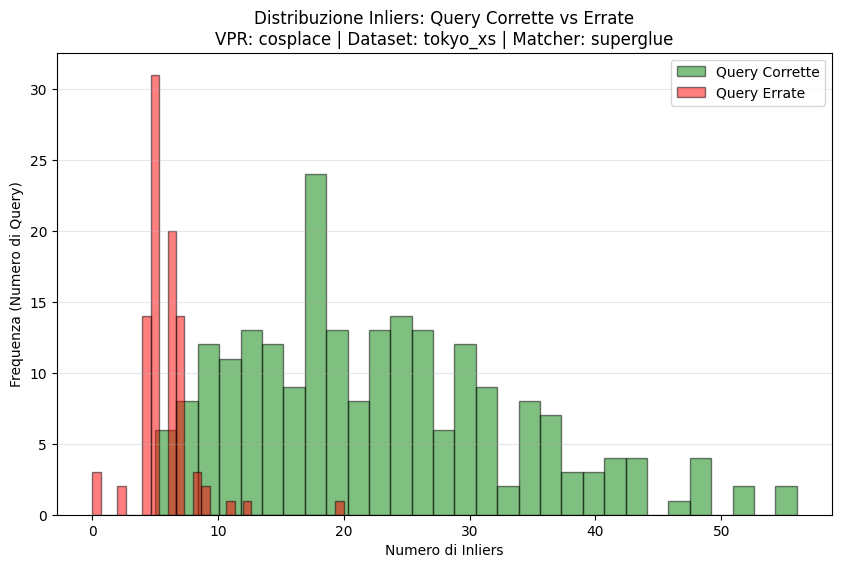

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superglue.png


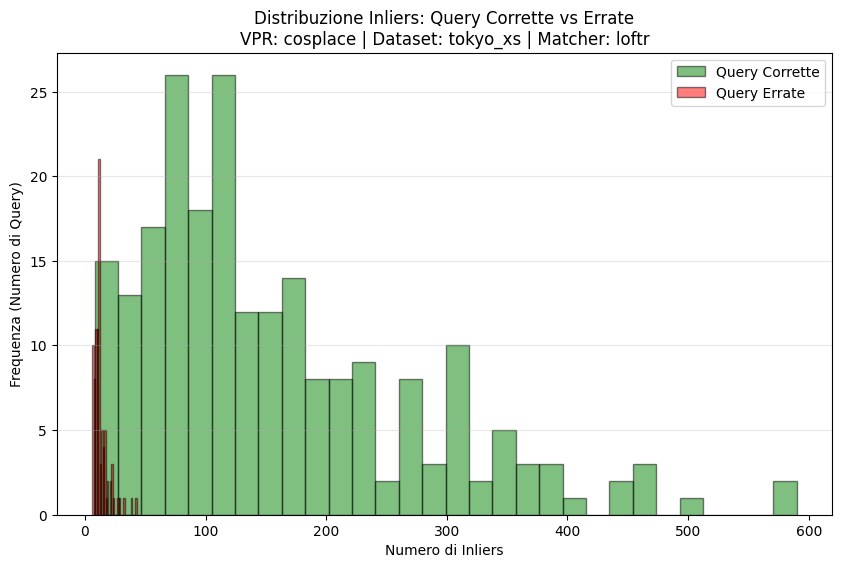

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_loftr.png


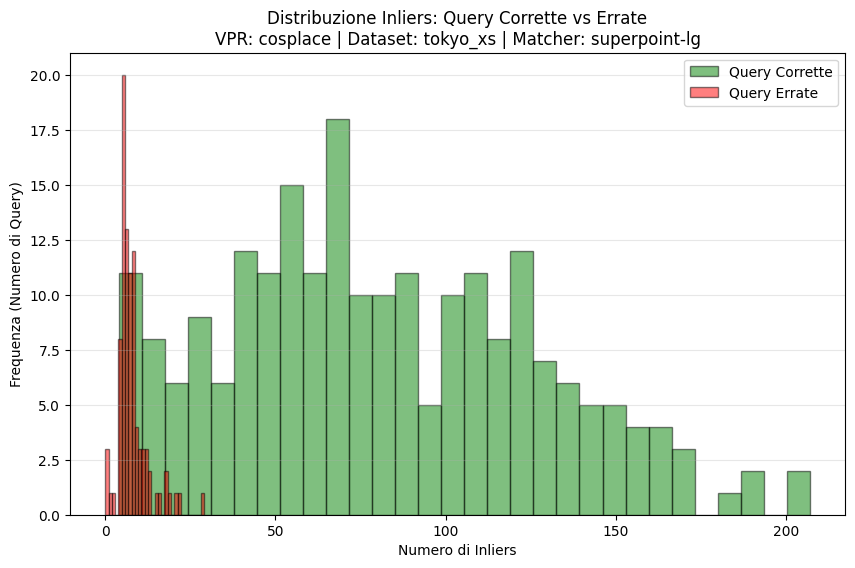

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superpoint-lg.png


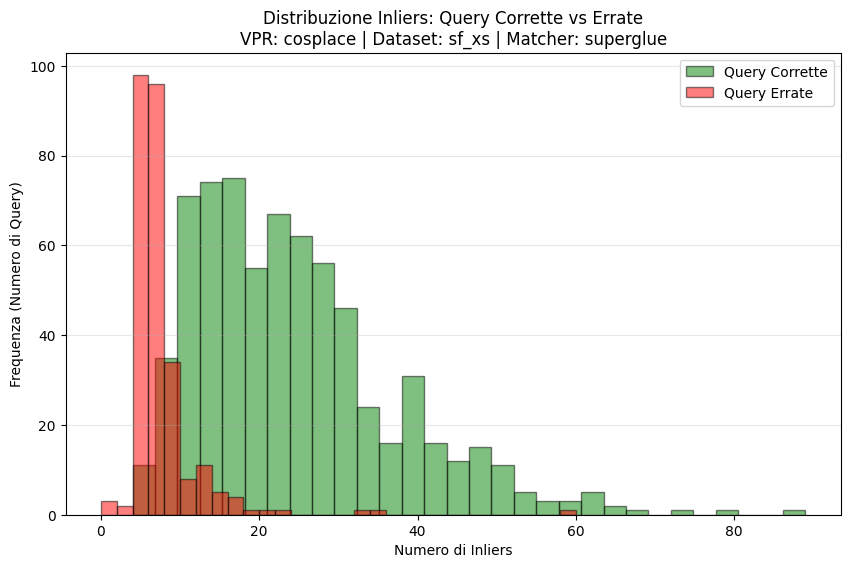

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superglue.png


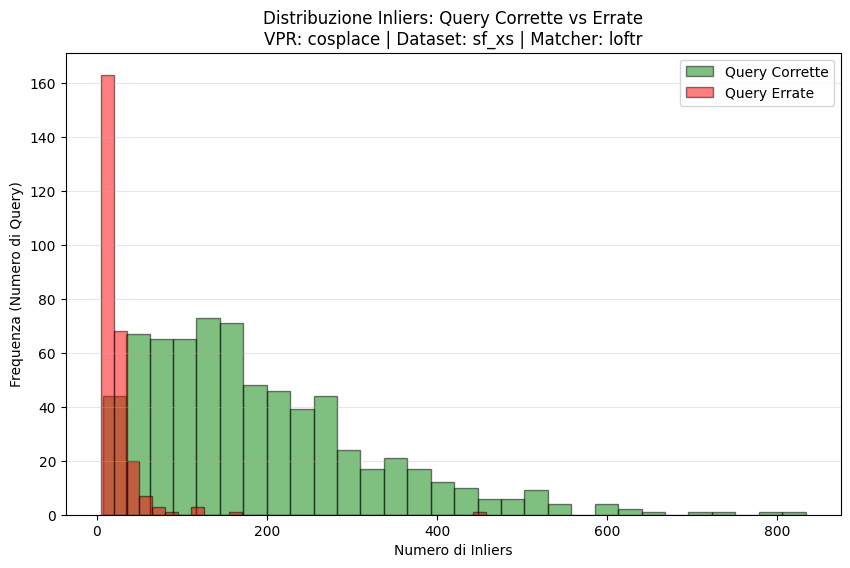

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_loftr.png


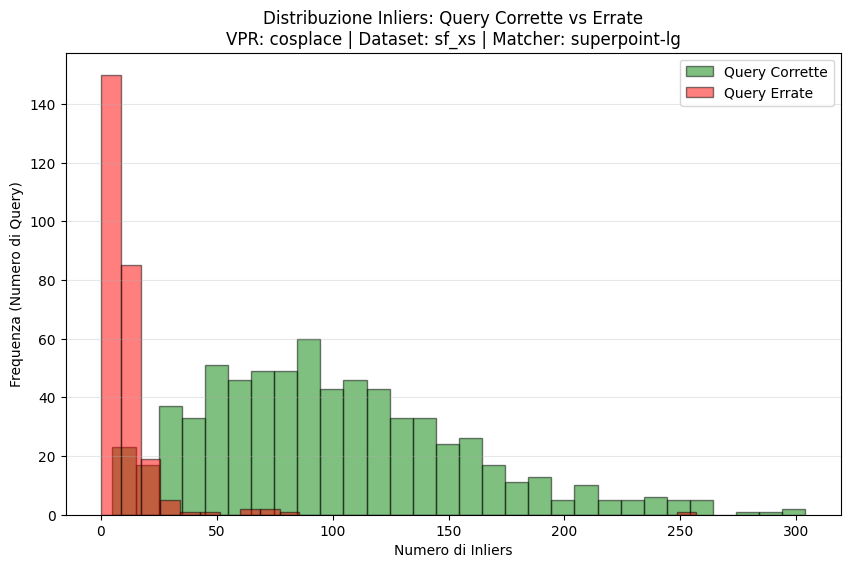

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superpoint-lg.png


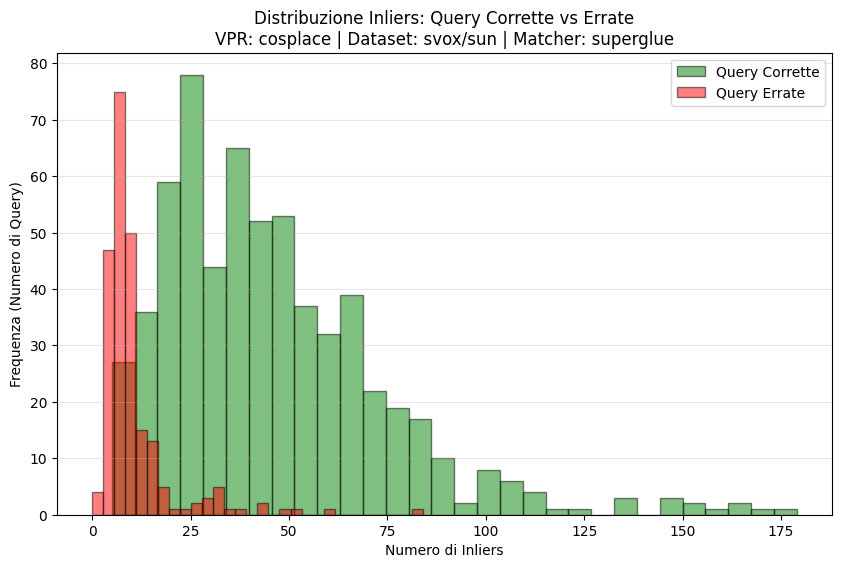

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superglue.png


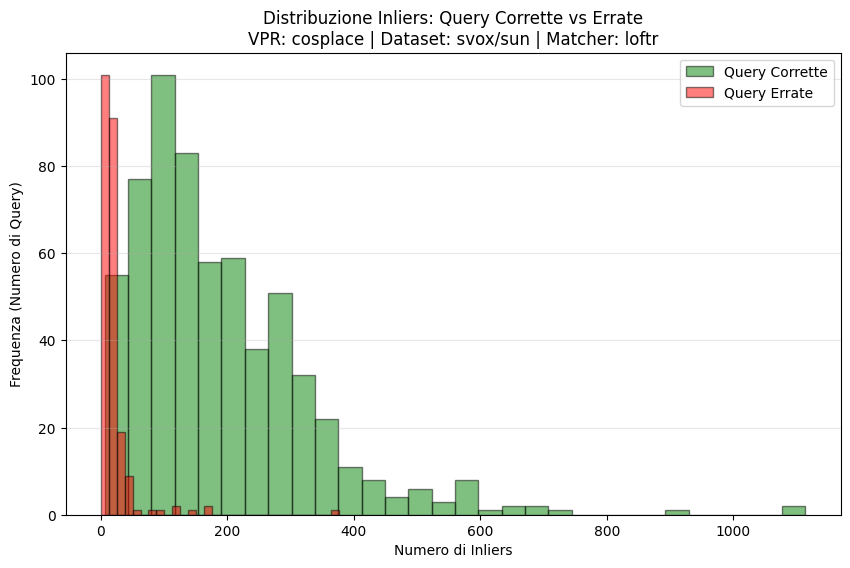

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_loftr.png


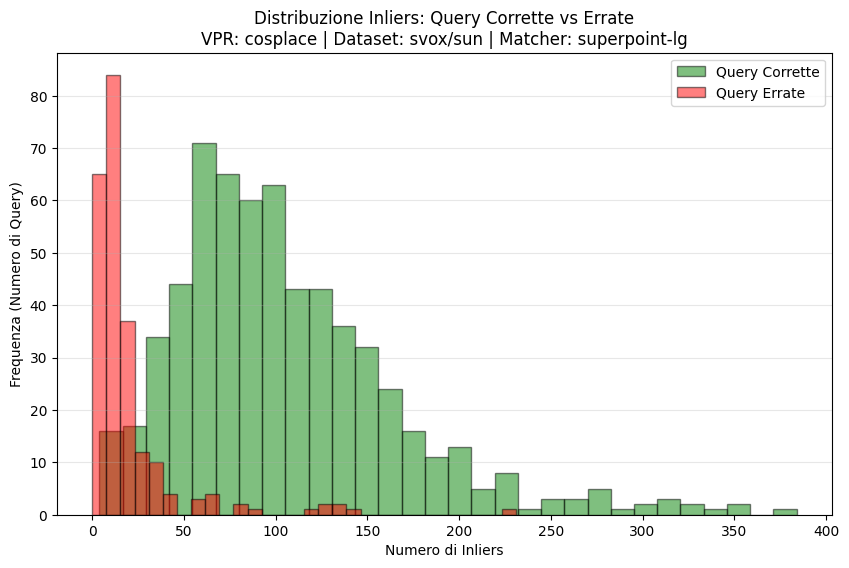

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superpoint-lg.png


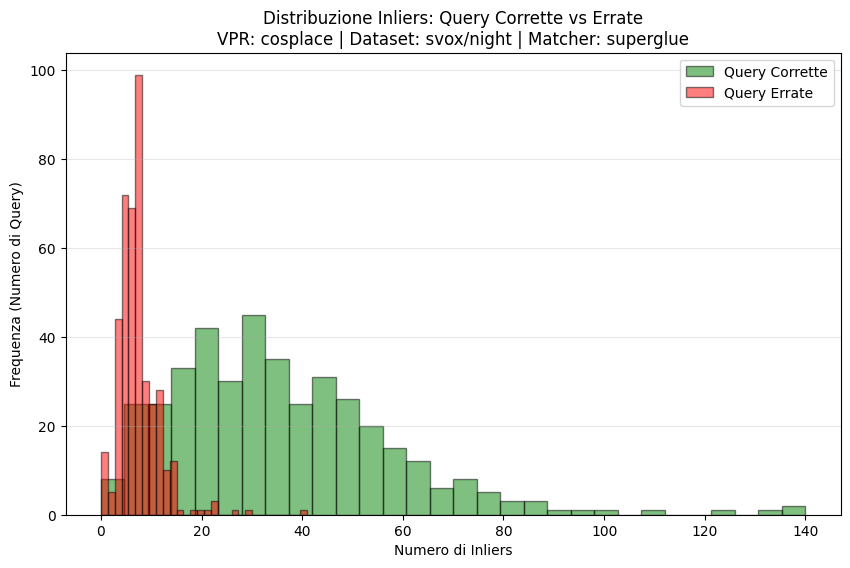

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superglue.png


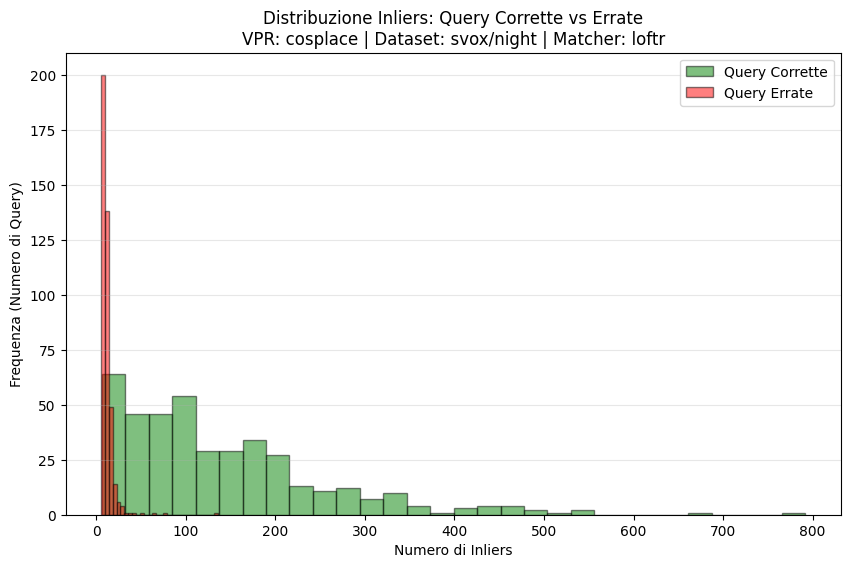

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_loftr.png


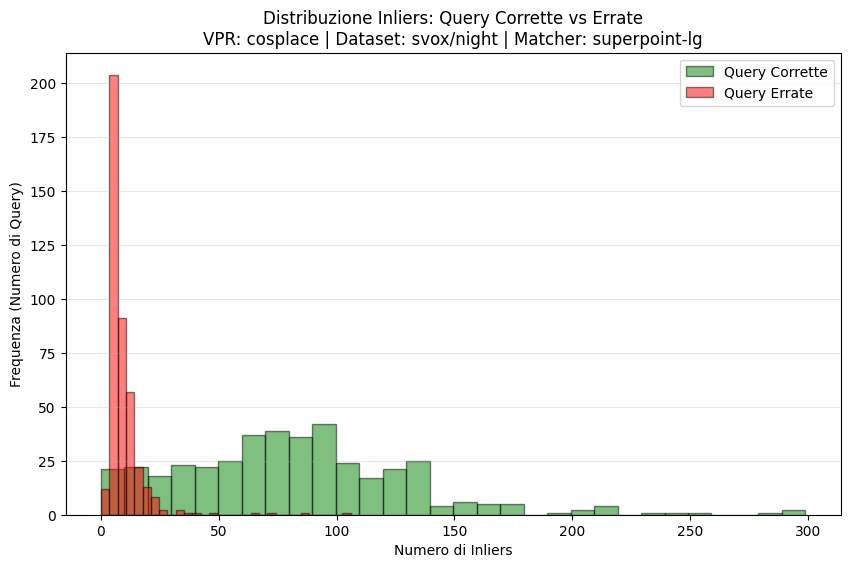

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superpoint-lg.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path


# Cicliamo solo per generare i grafici
for dataset in datasets:
    for method in methods:

        # Filtriamo il database in memoria per la combinazione corrente
        df_filtrato = df_risultati[
            (df_risultati['dataset'] == dataset) &
            (df_risultati['method'] == method)
        ]

        if df_filtrato.empty:
            continue

        # Separiamo corretti e sbagliati
        correct_inliers = df_filtrato[df_filtrato['base_correct'] == True]['rank1_inliers']
        wrong_inliers = df_filtrato[df_filtrato['base_correct'] == False]['rank1_inliers']

        plt.figure(figsize=(10, 6))
        plt.hist(correct_inliers, bins=30, alpha=0.5, label='Query Corrette', color='g', edgecolor='black')
        plt.hist(wrong_inliers, bins=30, alpha=0.5, label='Query Errate', color='r', edgecolor='black')

        plt.title(
            f'Distribuzione Inliers: Query Corrette vs Errate\n'
            f'VPR: {vpr_method} | Dataset: {dataset} | Matcher: {method}'
        )
        plt.xlabel('Numero di Inliers')
        plt.ylabel('Frequenza (Numero di Query)')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        # Salvataggio dentro la cartella Inliers
        save_dir = (
            Path(base_dir)
            / "Inliers"
            / vpr_method
            / dataset
        )

        save_dir.mkdir(parents=True, exist_ok=True)

        save_path = save_dir / f'istogramma_inliers_{method}.png'

        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Salvato: {save_path}")

## calcolo dell'hard threshold e salvataggio nel csv


📊 Dataset selezionato: SVOX/SUN | Matcher: SUPERPOINT-LG
📈 Numero massimo di inliers rilevato al Rank 1: 384

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 11
Performance all'incrocio -> Recall@1: 89.11% | Cost Saving: 89.11%



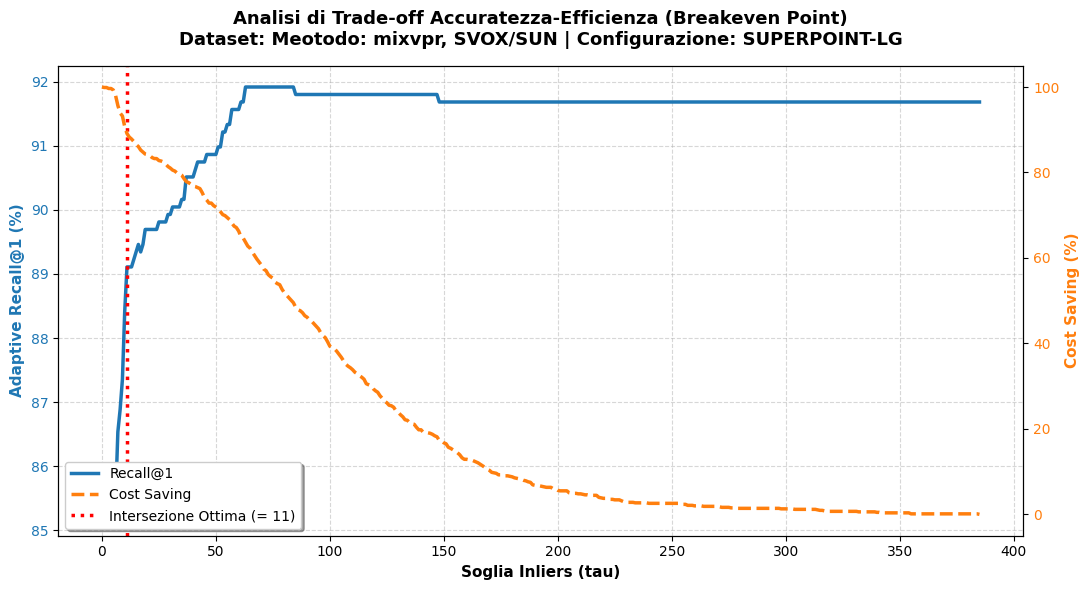

📊 Dataset selezionato: SVOX/SUN | Matcher: LOFTR
📈 Numero massimo di inliers rilevato al Rank 1: 1114

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 14
Performance all'incrocio -> Recall@1: 88.99% | Cost Saving: 89.93%



<Figure size 640x480 with 0 Axes>

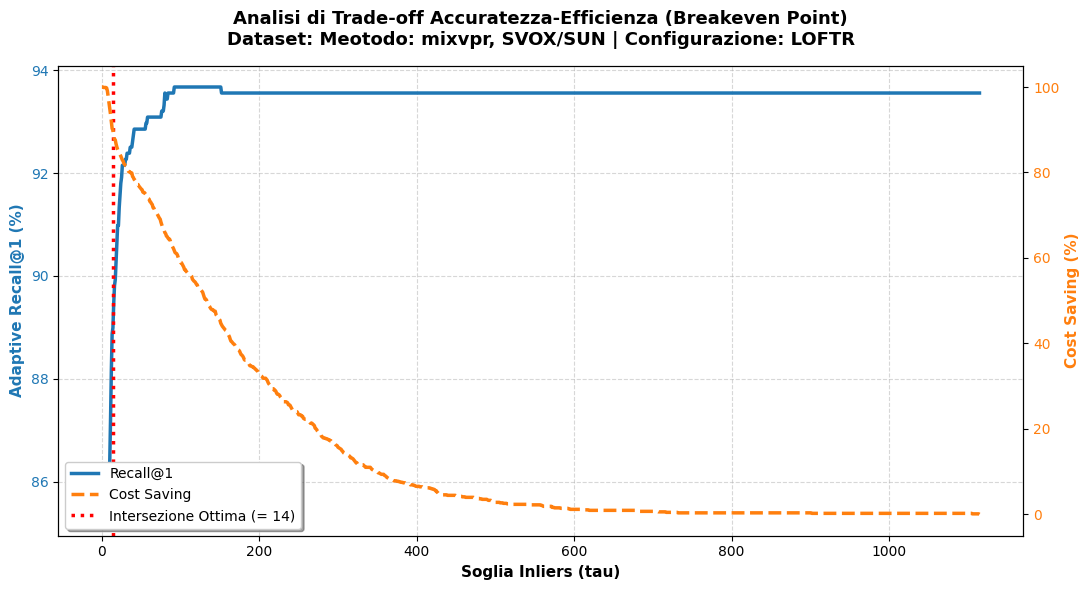

📊 Dataset selezionato: SVOX/NIGHT | Matcher: SUPERPOINT-LG
📈 Numero massimo di inliers rilevato al Rank 1: 297

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 8
Performance all'incrocio -> Recall@1: 75.09% | Cost Saving: 76.43%



<Figure size 640x480 with 0 Axes>

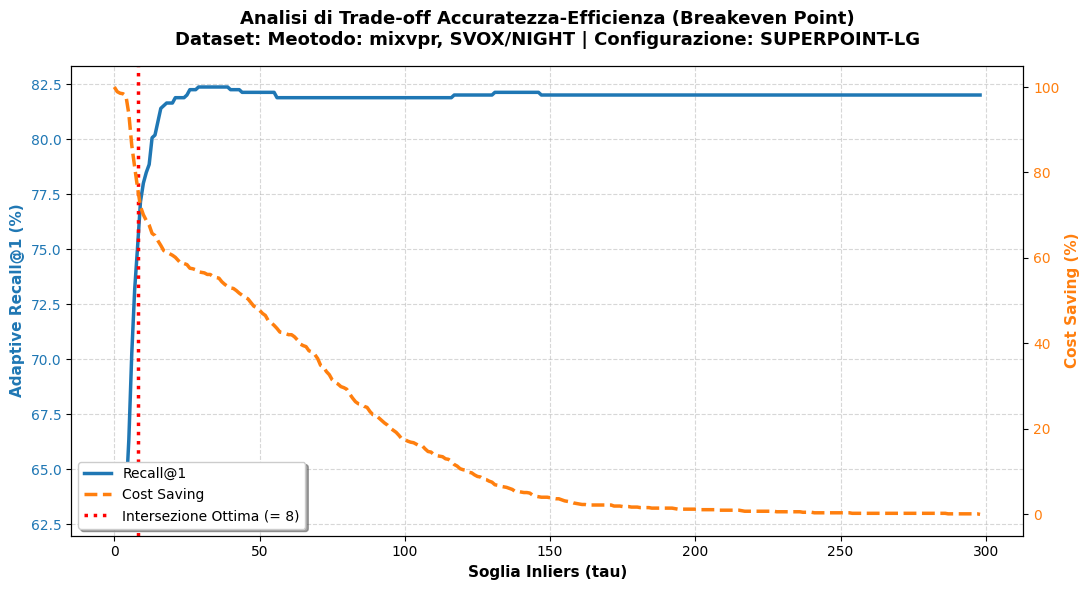

📊 Dataset selezionato: SVOX/NIGHT | Matcher: LOFTR
📈 Numero massimo di inliers rilevato al Rank 1: 792

🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!
Soglia ottima di inliers (tau): 11
Performance all'incrocio -> Recall@1: 75.46% | Cost Saving: 74.36%



<Figure size 640x480 with 0 Axes>

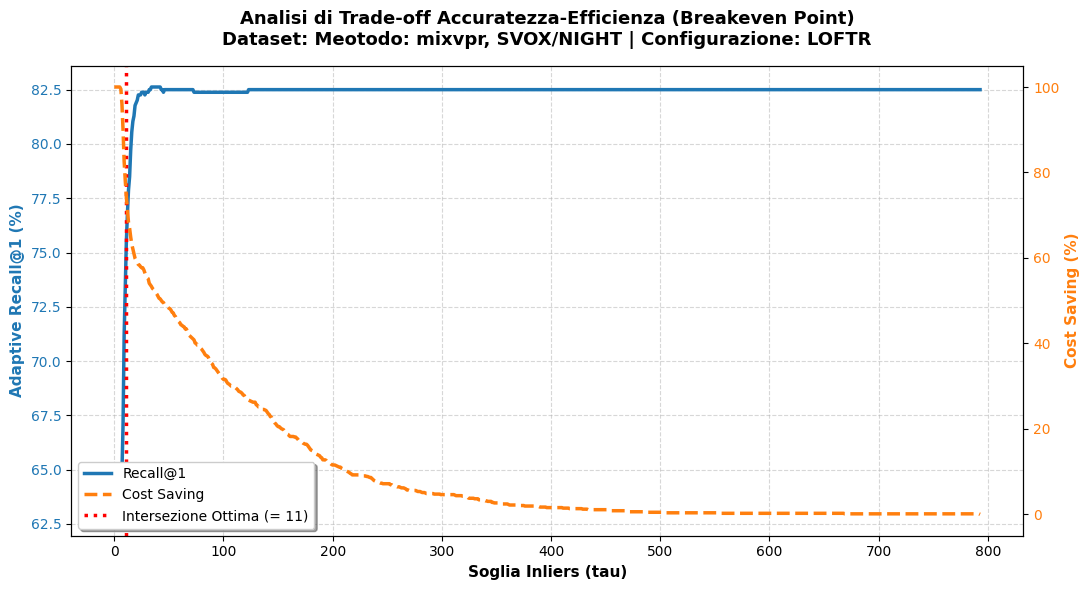

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training")
output_dir = Path(base_dir) / "Image_Matching_methods" / vpr_method

soglia_sun = []
soglia_night = []

# =================================================================
# 1. CONFIGURAZIONE SELEZIONE DATASET E METODO
# =================================================================
# Scegli lo split di training (es. 'svox/sun' o 'svox/night') su cui calcolare la soglia
datasets = ["svox/sun","svox/night"]
methods = ["superpoint-lg","loftr"]
for dataset in datasets:
  for method in methods:
    # Filtriamo il DataFrame globale (df_risultati) generato nella cella precedente
    df = df_risultati[(df_risultati["dataset"] == dataset) &
                            (df_risultati["method"] == method)].copy()

    # =================================================================
    # 2. CALCOLO DINAMICO DEL RANGE DI SOGLIE
    # =================================================================
    # Estraiamo il valore massimo di inliers per impostare il limite dell'asse X
    max_inliers = df["rank1_inliers"].max()
    print(f"📊 Dataset selezionato: {dataset.upper()} | Matcher: {method.upper()}")
    print(f"📈 Numero massimo di inliers rilevato al Rank 1: {max_inliers}")
# Generiamo il vettore delle soglie da testare (incluso il valore massimo reale grazie al +2)
    soglie_da_testare = np.arange(0, int(max_inliers) + 2)

    lista_recall = []
    lista_cost_saving = []

    # =================================================================
    # 3. CICLO DI SIMULAZIONE ADAPTIVE RE-RANKING
    # =================================================================
    for tau in soglie_da_testare:
        # REGOLA ADATTIVA:
        # Se inliers < tau -> query difficile -> esegui re-ranking completo (full_correct)
        # Se inliers >= tau -> query facile -> accetta il retrieval puro di base (base_correct)
        adaptive_correct = np.where(
            df["rank1_inliers"] < tau,
            df["full_correct"],
            df["base_correct"]
        )

        # Calcolo della percentuale di Recall@1 Adattivo
        recall_adattivo = adaptive_correct.mean() * 100
        lista_recall.append(recall_adattivo)

        # Calcolo del Cost Saving (% di query che hanno evitato il re-ranking geometrico)
        queries_risparmiate = (df["rank1_inliers"] >= tau).sum()
        cost_saving = (queries_risparmiate / len(df)) * 100
        lista_cost_saving.append(cost_saving)

    # =================================================================
    # 4. CALCOLO MATEMATICO DEL PUNTO DI INTERSEZIONE
    # =================================================================
    arr_recall = np.array(lista_recall)
    arr_cost_saving = np.array(lista_cost_saving)

    # Troviamo la soglia in cui la differenza assoluta tra le due curve è minima
    differenza_assoluta = np.abs(arr_recall - arr_cost_saving)
    indice_intersezione = np.argmin(differenza_assoluta)

    soglia_ottima = soglie_da_testare[indice_intersezione]
    valore_recall_incrocio = arr_recall[indice_intersezione]
    valore_costo_incrocio = arr_cost_saving[indice_intersezione]






    print("\n" + "="*60)
    print(f"🎯 PUNTO DI INTERSEZIONE (BREAKEVEN) IDENTIFICATO!")
    print(f"Soglia ottima di inliers (tau): {soglia_ottima}")
    print(f"Performance all'incrocio -> Recall@1: {valore_recall_incrocio:.2f}% | Cost Saving: {valore_costo_incrocio:.2f}%")
    print("="*60 + "\n")


    if dataset=="svox/sun":
      soglia_sun.append(soglia_ottima)



    else:
      soglia_night.append(soglia_ottima)

    # =================================================================
    # 5. GENERAZIONE DEL GRAFICO A DUE ASSI (TRADE-OFF)
    # =================================================================
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Configurazione Asse Sinistro (Y1): Recall@1
    color = 'tab:blue'
    ax1.set_xlabel('Soglia Inliers (tau)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Adaptive Recall@1 (%)', color=color, fontsize=11, fontweight='bold')
    line_rec = ax1.plot(soglie_da_testare, lista_recall, color=color, linewidth=2.5, label='Recall@1')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Configurazione Asse Destro (Y2): Cost Saving
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Cost Saving (%)', color=color, fontsize=11, fontweight='bold')
    line_cost = ax2.plot(soglie_da_testare, lista_cost_saving, color=color, linewidth=2.5,
                        linestyle='--', label='Cost Saving')
    ax2.tick_params(axis='y', labelcolor=color)

    # Disegna la linea verticale nel punto esatto di intersezione calcolato
    line_v = ax1.axvline(x=soglia_ottima, color='red', linestyle=':', linewidth=2.5,
                        label=f'Intersezione Ottima (= {soglia_ottima})')

    # Unificazione delle legende di assi diversi in un unico box pulito
    lines = line_rec + line_cost + [line_v]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower left', frameon=True, shadow=True, facecolor='white')

    # Titolo del grafico
    plt.title(f"Analisi di Trade-off Accuratezza-Efficienza (Breakeven Point)\nDataset: Meotodo: {vpr_method}, {dataset.upper()} | Configurazione: {method.upper()}",
              fontsize=13, fontweight='bold', pad=15)

    fig.tight_layout()
    plt.show()
    plt.savefig(output_dir / dataset / f'Tradeoff_{vpr_method}_{method}', dpi=300, bbox_inches='tight')

# media delle soglie e salvataggio sul file txt

In [21]:
media_sun = np.mean(soglia_sun)
media_night = np.mean(soglia_night)

txt_path = output_dir / "soglie_medie.txt"

with open(txt_path, "w") as f:

    # =========================
    # SUN
    # =========================
    f.write(f"soglia_sun_superpoint-lg = {soglia_sun[0]}\n")
    f.write(f"soglia_sun_loftr = {soglia_sun[1]}\n")
    f.write(f"media_soglia_sun = {media_sun:.2f}\n\n")

    # =========================
    # NIGHT
    # =========================
    f.write(f"soglia_night_superpoint-lg = {soglia_night[0]}\n")
    f.write(f"soglia_night_loftr = {soglia_night[1]}\n")
    f.write(f"media_soglia_night = {media_night:.2f}\n")

print(f"File salvato in: {txt_path}")

File salvato in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/training/Image_Matching_methods/mixvpr/soglie_medie.txt


# prova

In [ ]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ============================================================
# ESPERIMENTI ADAPTIVE RERANKING + TEMPI REALI
# confronto: FULL RERANKING vs ADAPTIVE RERANKING
# ============================================================


datasets = ['sf_xs', 'tokyo_xs', 'svox/sun', 'svox/night']
methods = ['superglue', 'loftr', 'superpoint-lg']

root_dir = Path(
    "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods"
)

base_dir = root_dir / vpr_method

soglia_csv = base_dir / "soglia_r1.csv"
tempi_csv = base_dir / "tabella_finale_tempi_query.csv"
output_csv = base_dir / "adaptive_vs_full_reranking_summary.csv"

print(f"📂 Metodo VPR selezionato: {vpr_method}")
print(f"📁 Cartella base: {base_dir}")


# ------------------------------------------------------------
# CONTROLLO FILE NECESSARI
# ------------------------------------------------------------

if not soglia_csv.exists():
    raise FileNotFoundError(
        f"Non trovo soglia_r1.csv:\n{soglia_csv}\n\n"
        "Devi prima eseguire la cella che crea soglia_r1.csv."
    )

if not tempi_csv.exists():
    raise FileNotFoundError(
        f"Non trovo tabella_finale_tempi_query.csv:\n{tempi_csv}\n\n"
        "Devi prima eseguire la cella che crea la tabella dei tempi."
    )

if "df_risultati" not in globals():
    raise NameError(
        "df_risultati non esiste in memoria.\n\n"
        "Devi prima eseguire la cella che crea df_risultati, "
        "cioè quella che estrae gli inliers dai file .torch."
    )


# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------

def evaluate_adaptive_threshold(queries, threshold):
    correct = 0
    n_easy_skip = 0
    n_hard_rerank = 0
    matching_pairs_adaptive = 0
    matching_pairs_full = 0

    for q in queries:

        k = int(q["k"])
        matching_pairs_full += k

        if int(q["rank1_inliers"]) >= threshold:
            # Query easy: tengo il rank-1 originale.
            matching_pairs_adaptive += 1
            n_easy_skip += 1
            correct += int(q["base_correct"])

        else:
            # Query hard: faccio full reranking.
            matching_pairs_adaptive += k
            n_hard_rerank += 1
            correct += int(q["full_correct"])

    n = len(queries)

    adaptive_r1 = 100 * correct / n if n > 0 else 0.0
    skip_pct = 100 * n_easy_skip / n if n > 0 else 0.0
    rerank_pct = 100 * n_hard_rerank / n if n > 0 else 0.0

    matching_pairs_vs_full_pct = (
        100 * matching_pairs_adaptive / matching_pairs_full
        if matching_pairs_full > 0 else 0.0
    )

    matching_pairs_saving_pct = 100 - matching_pairs_vs_full_pct

    return {
        "threshold": threshold,
        "adaptive_R@1": adaptive_r1,

        "n_easy_skip": n_easy_skip,
        "n_hard_rerank": n_hard_rerank,
        "skip_queries_%": skip_pct,
        "rerank_queries_%": rerank_pct,

        "matching_pairs_adaptive": matching_pairs_adaptive,
        "matching_pairs_full": matching_pairs_full,
        "matching_pairs_vs_full_%": matching_pairs_vs_full_pct,
        "matching_pairs_saving_%": matching_pairs_saving_pct,
    }


def get_reranking_timing(tempi_df, dataset, method):
    """
    Recupera i tempi reali dalla tabella_finale_tempi_query.csv.

    Usiamo solo:
        Matching_Mean_s
        Reranking_Mean_s

    Escludiamo:
        Global_Mean_s

    perché vogliamo confrontare solo:
        full reranking vs adaptive reranking.
    """

    row = tempi_df[
        (tempi_df["Dataset"].astype(str) == str(dataset)) &
        (tempi_df["Metodo"].astype(str) == str(method))
    ]

    if len(row) == 0:
        print(f"⚠️ Tempi non trovati per {dataset} / {method}. Uso zeri.")
        return {
            "matching_mean_s": 0.0,
            "reranking_mean_s": 0.0,
        }

    row = row.iloc[0]

    return {
        "matching_mean_s": float(row.get("Matching_Mean_s", 0.0)),
        "reranking_mean_s": float(row.get("Reranking_Mean_s", 0.0)),
    }


def add_reranking_time_estimates(res, timing, n_queries):
    """
    FULL RERANKING:
        tempo_full = tempo_matching_full + tempo_reranking_full

    ADAPTIVE RERANKING:
        tempo_adaptive =
            tempo_matching_full * frazione_matching_pairs_usati
            +
            tempo_reranking_full * frazione_query_rerankate

    Il retrieval globale NON è incluso.
    """

    matching_mean_s = timing["matching_mean_s"]
    reranking_mean_s = timing["reranking_mean_s"]

    matching_ratio = res["matching_pairs_vs_full_%"] / 100.0
    hard_query_ratio = res["rerank_queries_%"] / 100.0

    full_reranking_query_s = matching_mean_s + reranking_mean_s

    adaptive_reranking_query_s = (
        matching_mean_s * matching_ratio
        +
        reranking_mean_s * hard_query_ratio
    )

    full_reranking_total_s = n_queries * full_reranking_query_s
    adaptive_reranking_total_s = n_queries * adaptive_reranking_query_s

    delta_query_s = full_reranking_query_s - adaptive_reranking_query_s
    delta_total_s = full_reranking_total_s - adaptive_reranking_total_s

    if full_reranking_total_s > 0:
        reranking_time_saving_pct = 100 * (
            1 - adaptive_reranking_total_s / full_reranking_total_s
        )
    else:
        reranking_time_saving_pct = np.nan

    res["matching_mean_s"] = matching_mean_s
    res["reranking_mean_s"] = reranking_mean_s

    res["full_reranking_query_s"] = full_reranking_query_s
    res["adaptive_reranking_query_s"] = adaptive_reranking_query_s

    res["full_reranking_query_ms"] = full_reranking_query_s * 1000
    res["adaptive_reranking_query_ms"] = adaptive_reranking_query_s * 1000

    res["reranking_delta_query_s"] = delta_query_s
    res["reranking_delta_query_ms"] = delta_query_s * 1000

    res["full_reranking_total_s"] = full_reranking_total_s
    res["adaptive_reranking_total_s"] = adaptive_reranking_total_s

    res["full_reranking_total_min"] = full_reranking_total_s / 60
    res["adaptive_reranking_total_min"] = adaptive_reranking_total_s / 60

    res["reranking_delta_total_s"] = delta_total_s
    res["reranking_delta_total_min"] = delta_total_s / 60

    res["reranking_time_saving_%"] = reranking_time_saving_pct

    return res


# ------------------------------------------------------------
# CARICO CSV
# ------------------------------------------------------------

soglie_df = pd.read_csv(soglia_csv)
tempi_df = pd.read_csv(tempi_csv)

all_results = []


# ------------------------------------------------------------
# CONTROLLO COLONNE df_risultati
# ------------------------------------------------------------

required_cols = [
    "dataset",
    "method",
    "k",
    "rank1_inliers",
    "base_correct",
    "full_correct"
]

missing_cols = [col for col in required_cols if col not in df_risultati.columns]

if len(missing_cols) > 0:
    raise ValueError(
        "Nel dataframe df_risultati mancano queste colonne:\n"
        f"{missing_cols}\n\n"
        "Controlla la cella che crea df_risultati."
    )


# ------------------------------------------------------------
# CICLO ESPERIMENTI
# ------------------------------------------------------------

print("\nAdaptive reranking: confronto full vs adaptive\n")

for _, row in soglie_df.iterrows():

    dataset = row["dataset"]
    method = row["method"]

    r1_base_log = row["r1_globale"]
    r1_full_log = row["r1_reranking"]
    soglia_recall = row["soglia_recall"]

    # --------------------------------------------------------
    # QUI NON USIAMO PIÙ load_experiment_data()
    # Usiamo direttamente df_risultati
    # --------------------------------------------------------

    df_subset = df_risultati[
        (df_risultati["dataset"].astype(str) == str(dataset)) &
        (df_risultati["method"].astype(str) == str(method))
    ].copy()

    if df_subset.empty:
        print(f"⚠️ {dataset:<10} | {method:<15} | nessuna riga trovata in df_risultati")
        continue

    # Conversioni di sicurezza
    df_subset["k"] = df_subset["k"].astype(int)
    df_subset["rank1_inliers"] = df_subset["rank1_inliers"].astype(int)
    df_subset["base_correct"] = df_subset["base_correct"].astype(int)
    df_subset["full_correct"] = df_subset["full_correct"].astype(int)

    queries = df_subset.to_dict("records")
    files_skipped = 0

    timing = get_reranking_timing(tempi_df, dataset, method)

    base_r1_check = 100 * np.mean([q["base_correct"] for q in queries])
    full_r1_check = 100 * np.mean([q["full_correct"] for q in queries])

    max_inliers = int(max(q["rank1_inliers"] for q in queries))

    threshold_results = []

    for threshold in range(0, max_inliers + 2):

        res = evaluate_adaptive_threshold(queries, threshold)

        res = add_reranking_time_estimates(
            res=res,
            timing=timing,
            n_queries=len(queries)
        )

        res["dataset"] = dataset
        res["method"] = method

        res["n_queries"] = len(queries)
        res["files_skipped"] = files_skipped
        res["avg_topK"] = float(np.mean([q["k"] for q in queries]))

        res["r1_base_log"] = r1_base_log
        res["r1_full_log"] = r1_full_log
        res["soglia_recall"] = soglia_recall

        res["r1_base_check"] = base_r1_check
        res["r1_full_check"] = full_r1_check

        res["loss_vs_full_check"] = full_r1_check - res["adaptive_R@1"]
        res["valid"] = res["adaptive_R@1"] >= soglia_recall

        threshold_results.append(res)

    threshold_df = pd.DataFrame(threshold_results)

    curve_path = base_dir / dataset / f"adaptive_curve_full_vs_adaptive_reranking_{method}.csv"
    curve_path.parent.mkdir(parents=True, exist_ok=True)
    threshold_df.to_csv(curve_path, index=False)

    valid_df = threshold_df[threshold_df["valid"] == True].copy()

    if len(valid_df) == 0:
        best = threshold_df.sort_values(
            by=["adaptive_R@1"],
            ascending=False
        ).iloc[0]
    else:
        best = valid_df.sort_values(
            by=[
                "adaptive_reranking_query_s",
                "matching_pairs_vs_full_%",
                "rerank_queries_%",
                "threshold"
            ],
            ascending=[True, True, True, True]
        ).iloc[0]

    all_results.append(best.to_dict())

    print(
        f"{dataset:<10} | {method:<15} | "
        f"thr={int(best['threshold']):>4} | "
        f"R@1={best['adaptive_R@1']:>6.2f}% | "
        f"soglia={best['soglia_recall']:>6.2f}% | "
        f"full={best['full_reranking_query_ms']:>8.2f} ms/q | "
        f"adaptive={best['adaptive_reranking_query_ms']:>8.2f} ms/q | "
        f"delta={best['reranking_delta_query_ms']:>8.2f} ms/q | "
        f"saving={best['reranking_time_saving_%']:>6.2f}%"
    )


# ------------------------------------------------------------
# SUMMARY FINALE
# ------------------------------------------------------------

if len(all_results) > 0:

    results_df = pd.DataFrame(all_results)

    results_df = results_df[
        [
            "dataset",
            "method",
            "threshold",
            "adaptive_R@1",
            "soglia_recall",
            "valid",

            "r1_base_log",
            "r1_full_log",
            "r1_base_check",
            "r1_full_check",
            "loss_vs_full_check",

            "n_easy_skip",
            "n_hard_rerank",
            "skip_queries_%",
            "rerank_queries_%",

            "matching_pairs_adaptive",
            "matching_pairs_full",
            "matching_pairs_vs_full_%",
            "matching_pairs_saving_%",

            "matching_mean_s",
            "reranking_mean_s",

            "full_reranking_query_s",
            "adaptive_reranking_query_s",
            "full_reranking_query_ms",
            "adaptive_reranking_query_ms",

            "reranking_delta_query_s",
            "reranking_delta_query_ms",

            "full_reranking_total_s",
            "adaptive_reranking_total_s",
            "full_reranking_total_min",
            "adaptive_reranking_total_min",

            "reranking_delta_total_s",
            "reranking_delta_total_min",

            "reranking_time_saving_%",

            "avg_topK",
            "n_queries",
            "files_skipped",
        ]
    ]

    results_df.to_csv(output_csv, index=False)

    print("\n✅ Summary salvato in:")
    print(output_csv)

    display(results_df)

else:
    print("❌ Nessun risultato prodotto.")

📂 Metodo VPR selezionato: cosplace
📁 Cartella base: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace

Adaptive reranking: confronto full vs adaptive

sf_xs      | superglue       | thr=   7 | R@1= 78.99% | soglia= 78.46% | full= 2329.70 ms/q | adaptive=  478.85 ms/q | delta= 1850.85 ms/q | saving= 79.45%
sf_xs      | loftr           | thr=  21 | R@1= 79.09% | soglia= 78.78% | full= 4565.28 ms/q | adaptive=  975.87 ms/q | delta= 3589.41 ms/q | saving= 78.62%
sf_xs      | superpoint-lg   | thr=  10 | R@1= 80.85% | soglia= 79.74% | full= 4469.11 ms/q | adaptive=  996.35 ms/q | delta= 3472.76 ms/q | saving= 77.71%
tokyo_xs   | superglue       | thr=   7 | R@1= 81.59% | soglia= 80.96% | full= 2407.93 ms/q | adaptive=  639.80 ms/q | delta= 1768.13 ms/q | saving= 73.43%
tokyo_xs   | loftr           | thr=  18 | R@1= 82.86% | soglia= 82.72% | full= 4969.74 ms/q | adaptive= 1491.38 ms/q | delta= 3478.37 ms/q | saving= 69.99%
tokyo_xs  

,dataset,method,threshold,adaptive_R@1,soglia_recall,valid,r1_base_log,r1_full_log,r1_base_check,r1_full_check,...,full_reranking_total_s,adaptive_reranking_total_s,full_reranking_total_min,adaptive_reranking_total_min,reranking_delta_total_s,reranking_delta_total_min,reranking_time_saving_%,avg_topK,n_queries,files_skipped
0,sf_xs,superglue,7,78.985507,78.46,True,69.9,80.6,72.360248,83.954451,...,2250.492132,462.573000,37.508202,7.709550,1787.919132,29.798652,79.445696,20.0,966,0
1,sf_xs,loftr,21,79.089027,78.78,True,69.9,81.0,72.360248,83.850932,...,4410.064344,942.690958,73.501072,15.711516,3467.373386,57.789556,78.624100,20.0,966,0
2,sf_xs,superpoint-lg,10,80.848861,79.74,True,69.9,82.2,72.360248,85.093168,...,4317.159294,962.473329,71.952655,16.041222,3354.685964,55.911433,77.705865,20.0,966,0
3,tokyo_xs,superglue,7,81.587302,80.96,True,70.8,83.5,70.793651,83.809524,...,758.499210,201.536896,12.641654,3.358948,556.962314,9.282705,73.429518,20.0,315,0
4,tokyo_xs,loftr,18,82.857143,82.72,True,70.8,85.7,70.793651,85.714286,...,1565.468730,469.783161,26.091145,7.829719,1095.685569,18.261426,69.990895,20.0,315,0
5,tokyo_xs,superpoint-lg,11,84.126984,83.52,True,70.8,86.7,70.793651,86.349206,...,1511.667045,461.728424,25.194451,7.695474,1049.938621,17.498977,69.455680,20.0,315,0
6,svox/sun,superglue,15,85.831382,85.28,True,73.2,88.3,73.185012,88.290398,...,2081.903404,662.580245,34.698390,11.043004,1419.323159,23.655386,68.174304,20.0,854,0
7,svox/sun,loftr,26,86.885246,86.88,True,73.2,90.3,73.185012,90.398126,...,4239.221840,1238.859085,70.653697,20.647651,3000.362755,50.006046,70.776262,20.0,854,0
8,svox/sun,superpoint-lg,24,86.182670,86.08,True,73.2,89.3,73.185012,89.578454,...,4081.853552,1116.519917,68.030893,18.608665,2965.333635,49.422227,72.646742,20.0,854,0
9,svox/night,superglue,10,66.464156,66.32,True,49.2,70.6,49.210207,71.081409,...,1934.811275,896.742813,32.246855,14.945714,1038.068462,17.301141,53.652182,20.0,823,0


In [ ]:
wandb.log({
    "Distribuzione Inliers/Corrette": wandb.Histogram(correct_inliers),
    "Distribuzione Inliers/Errate": wandb.Histogram(wrong_inliers)
})

run.finish()

**Esperimenti adaptive con hard threshold scelte sopra vs full rerank**